In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ---------- settings ----------
outdir = Path("plots")
outdir.mkdir(exist_ok=True)

infile = "./haplotypes_min10_lc0.01.csv"

# ---------- load ----------
df = pd.read_csv(infile)

# Accuracy: REF correctly assigned to H2
df["accurate"] = df["REF"].astype(str) == df["H2"].astype(str)

# ---------- summarise ----------
stage_summary = (
    df.groupby("Stage", dropna=False)["accurate"]
      .agg(
          n_pairs="size",
          n_correct="sum",
          accuracy="mean"
      )
      .reset_index()
)

stage_summary["Stage"] = stage_summary["Stage"].astype(str)
stage_summary["label"] = "Stage " + stage_summary["Stage"]

overall = pd.DataFrame({
    "Stage": ["Overall"],
    "label": ["Overall"],
    "n_pairs": [len(df)],
    "n_correct": [df["accurate"].sum()],
    "accuracy": [df["accurate"].mean()],
})

summary = pd.concat([stage_summary, overall], ignore_index=True)
summary["n_incorrect"] = summary["n_pairs"] - summary["n_correct"]
summary["pct_accuracy"] = summary["accuracy"] * 100
summary["pct_incorrect"] = 100 - summary["pct_accuracy"]

summary["plot_order"] = summary["Stage"].apply(
    lambda x: 999 if x == "Overall" else float(x)
)
summary = summary.sort_values("plot_order").reset_index(drop=True)




def save_all(fig, stem):
    for ext in ["png", "pdf", "svg", "eps"]:
        fig.savefig(
            outdir / f"{stem}.{ext}",
            dpi=300,
            bbox_inches="tight",
            transparent=True,
        )

    print(f"Wrote: {outdir / stem}.png/pdf/svg/eps")


In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Wrote: plots/phasing_accuracy_lollipop_by_stage_40x40mm.png/pdf/svg/eps


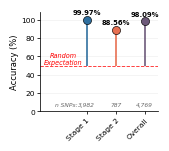

In [34]:
# ============================================================
# 40 mm × 40 mm lollipop plot: phasing accuracy by stage
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- figure size ----------
MM_PER_INCH = 25.4
FIG_WIDTH_MM = 40
FIG_HEIGHT_MM = 40
FIGSIZE = (FIG_WIDTH_MM / MM_PER_INCH, FIG_HEIGHT_MM / MM_PER_INCH)

# ---------- publication-style font settings for small panel ----------
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    "font.size": 5.5,
    "axes.labelsize": 6.0,
    "axes.titlesize": 6.2,
    "xtick.labelsize": 5.4,
    "ytick.labelsize": 5.4,

    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,
})

# ---------- order: Stage 1, Stage 2, Overall ----------
def clean_stage_label(x):
    if str(x) == "Overall":
        return "Overall"
    return f"Stage {int(float(x))}"


summary["label"] = summary["Stage"].apply(clean_stage_label)

summary["plot_order"] = summary["Stage"].apply(
    lambda x: 999 if str(x) == "Overall" else float(x)
)

summary = summary.sort_values("plot_order").reset_index(drop=True)

# ---------- colours ----------
color_map = {
    "Stage 1": "#2F6F9F",
    "Stage 2": "#E76F51",
    "Overall": "#6D597A",
}

# ============================================================
# Plot: compact accuracy lollipop plot
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

x = np.arange(len(summary)) * 0.62
y = summary["pct_accuracy"].values
point_colors = summary["label"].map(color_map).tolist()

# ---------- lollipops ----------
for xi, yi, c in zip(x, y, point_colors):
    ax.vlines(
        x=xi,
        ymin=50,
        ymax=yi,
        linewidth=1.25,
        alpha=0.95,
        color=c,
        zorder=2,
    )

    ax.scatter(
        xi,
        yi,
        s=34,
        color=c,
        edgecolor="black",
        linewidth=0.45,
        zorder=3,
    )

# ---------- random expectation ----------
ax.axhline(
    50,
    linestyle="--",
    linewidth=0.65,
    color="red",
    alpha=0.8,
)

ax.text(
    x.min() - 0.5,
    50,
    "Random\nExpectation",
    fontsize=4.7,
    color="red",
    ha="center",
    va="bottom",
    style="italic",
)

# ---------- value annotations ----------
for i, row in summary.iterrows():
    ax.annotate(
        f'{row["pct_accuracy"]:.2f}%',
        xy=(x[i], row["pct_accuracy"]),
        xytext=(0, 3.2),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=4.9,
        fontweight="bold",
    )

    ax.annotate(
        f'{int(row["n_pairs"]):,}',
        xy=(x[i], 0),
        xytext=(0, 3.2),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=4.3,
        color="dimgray",
        style="italic",
    )

# ---------- axes ----------
ax.set_xticks(x)
ax.set_xticklabels(summary["label"], rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlim(x.min() - 1, x.max() + 0.28)
ax.set_ylim(0, 108)

ax.set_ylabel("Accuracy (%)", labelpad=1.5)
# ax.set_title("Phasing accuracy", pad=3)

# ---------- SNP count label ----------
ax.text(
    x.min() - 0.20,
    0.045,
    "n SNPs:",
    transform=ax.get_xaxis_transform(),
    ha="right",
    va="bottom",
    fontsize=4.3,
    color="dimgray",
    style="italic",
)

# ---------- styling ----------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.22, linewidth=0.45)
ax.set_axisbelow(True)

ax.tick_params(axis="x", pad=1.5)
ax.tick_params(axis="y", pad=1.2)

fig.subplots_adjust(
    left=0.23,
    right=0.98,
    top=0.87,
    bottom=0.24,
)

save_all(fig, "phasing_accuracy_lollipop_by_stage_40x40mm")
plt.show()